Given that the field has not converged on gold-standard assessment metrics, ere, we visualize the predictions in embedding space and assess via the "eyeball test". This tends to be reasonably indicative of model's predictive performance, though more qualitative than quantitative. 

In [1]:
import warnings

warnings.resetwarnings()

warnings.filterwarnings(
    "ignore",
    category=FutureWarning,
    message=r".*__version__ is deprecated.*"
)

warnings.filterwarnings(
    "ignore",
    category=UserWarning,
    message=r"Observation names are not unique.*"
)

warnings.filterwarnings(
    "ignore",
    module=r"scanpy(\..*)?$"
)

warnings.filterwarnings(
    "ignore",
    module=r"anndata(\..*)?$"
)

warnings.filterwarnings("ignore", module=r"scanpy(\..*)?$")
warnings.filterwarnings("ignore", module=r"anndata(\..*)?$")
warnings.filterwarnings("ignore", message="Observation names are not unique.*")
warnings.filterwarnings("ignore", message="`__version__` is deprecated.*")
warnings.filterwarnings('ignore', category=FutureWarning, module='scanpy')
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=ImportWarning)

from anndata._warnings import ImplicitModificationWarning
warnings.filterwarnings(
    "ignore",
    category=ImplicitModificationWarning
)

In [2]:
import os
import sys
import warnings
from contextlib import contextmanager
import copy

from tqdm import trange

import numpy as np
import pandas as pd
import scanpy as sc

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns
sns.set_context(
    "paper",
    rc={
        "axes.labelsize": 18,
        "axes.titlesize": 20,
        "legend.fontsize": 12,
        "xtick.labelsize": 16,
        "ytick.labelsize": 16,
    }
)

import sys
sys.path.insert(1, '../.')
from McCauley_utils import all_data

sys.path.insert(1, '../../.') 
from notebook_utils import get_split, pb_y_pred

sclembas = '/home/hmbaghda/Projects/scLEMBAS'
sys.path.insert(1, os.path.join(sclembas))
from scLEMBAS import io
from scLEMBAS import latent_separation as ls
from scLEMBAS.metrics import distances

/orcd/pool/005/hmbaghda/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
seed = 888
data_path = '/home/hmbaghda/orcd/pool/scLEMBAS/analysis'
author = 'McCauley'

n_cores = 30
os.environ["OMP_NUM_THREADS"] = str(1)
os.environ["MKL_NUM_THREADS"] = str(1)
os.environ["OPENBLAS_NUM_THREADS"] = str(1)
os.environ["VECLIB_MAXIMUM_THREADS"] = str(1)
os.environ["NUMEXPR_NUM_THREADS"] = str(1)

In [4]:
(sn_ppis, tf_adata, adata, expr, source_label, target_label, weight_label, 
 stimulation_label, inhibition_label, cat_col, pert_col, ctrl_pert) = all_data

merged_adatas = io.read_pickled_object(
    os.path.join(data_path, 'processed', '{}_scLEMBAS_model_predictions.pickle'.format(author))
)

In [5]:
n_folds = 5
ls_label_dict = {
    'pls': 'LV', 
    'pca': 'PC'
}

# Test Predictions

In [6]:
def load_test_tfadata(fold):
    key = 'none_{}'.format(fold)
    tf_adata_merged = merged_adatas[key].copy()

    split = get_split(fold, author)
    test_conds = split['test_conds']

    test_cond_mask = tf_adata_merged.obs.condition.isin(test_conds)
    tf_adata_test = tf_adata_merged[test_cond_mask,:].copy()
    assert 'predicted_ctrl' not in tf_adata_test.obs.batch, 'Unexpected training predictions present'

    predicted_mask = (tf_adata_test.obs.batch == 'predicted')

    tf_adata_predicted = tf_adata_test[predicted_mask, :].copy()
    tf_adata_actual = tf_adata_test[~predicted_mask, :].copy()
    assert len(np.where(tf_adata.obs.condition.isin(test_conds))[0]) == tf_adata_actual.shape[0], 'Incorrect subsetting of actual data'

    return tf_adata_actual, tf_adata_predicted


def plot_fold_column_(tf_adata_actual, tf_adata_predicted, 
                     ls, group_col, ax, min_points_kde = 75, is_last_col = False):

    adata_dict = {
        'Actual': tf_adata_actual,
        'Predicted': tf_adata_predicted
    }

    cats = None

    for (i, (adata_type, adata)) in enumerate(adata_dict.items()):

        viz_df = pd.DataFrame(adata.obsm['X_{}'.format(ls)])
        viz_df.columns = ['{}{}'.format(ls_label_dict[ls], i+1) for i in range(viz_df.shape[1])]

        viz_df[group_col] = adata.obs[group_col].astype(str).apply(lambda x: x.replace('^', ', ')).tolist()
        viz_df[group_col].apply
        cats = sorted(viz_df[group_col].unique())
        viz_df[group_col] = pd.Categorical(viz_df[group_col],
                                           categories = cats, ordered = True)

        # --- KDE for groups that can support it; scatter fallback for tiny / singular groups ---

        small_cats = []
        for cat in cats:
            tmp = viz_df[viz_df[group_col] == cat]

            # too few points
            if tmp.shape[0] < min_points_kde:
                small_cats.append(cat)
                continue

            # singular / near-singular geometry (no 2D contour possible)
            xvar = np.var(tmp['{}1'.format(ls_label_dict[ls])].values)
            yvar = np.var(tmp['{}2'.format(ls_label_dict[ls])].values)
            if (xvar <= 1e-12) or (yvar <= 1e-12):
                small_cats.append(cat)

        viz_df_kde = viz_df[~viz_df[group_col].isin(small_cats)]

        if viz_df_kde.shape[0] > 0:
            sns.kdeplot(data = viz_df_kde,
                        x = '{}1'.format(ls_label_dict[ls]),
                        y = '{}2'.format(ls_label_dict[ls]),
                        hue = group_col, fill = False, levels = 5,
                        warn_singular = False,
                        ax = ax[i])

        # scatter overlay for small / singular groups (so they never disappear)
        palette = sns.color_palette(n_colors = len(cats))
        color_map = {cat: color for (cat, color) in zip(cats, palette)}

        for cat in small_cats:
            tmp = viz_df[viz_df[group_col] == cat]
            ax[i].scatter(tmp['{}1'.format(ls_label_dict[ls])],
                          tmp['{}2'.format(ls_label_dict[ls])],
                          s = 12, alpha = 0.9,
                          color = color_map[cat])

        # titles: only top row
        if i == 0:
            ax[i].set_title('Fold: {}'.format(fold + 1))
        else:
            ax[i].set_title('')

        # clear seaborn auto-legend
        ax[i].legend_.remove() if ax[i].legend_ is not None else None

        # right-side y-axis labels only on final column
        if is_last_col:
            ax_r = ax[i].twinx()                 
            ax_r.set_ylabel(adata_type, labelpad = 20)
            ax_r.set_yticks([])              
            ax_r.tick_params(right=False)
            ax_r.spines['right'].set_visible(False)
#         else:
#             ax[i].set_ylabel('')

    # ensure smae bounds (robust quantiles)
    xmin, xmax, ymin, ymax = np.inf, -np.inf, np.inf, -np.inf

    q_lo = 0.005
    q_hi = 0.995

    for (adata_type, adata) in adata_dict.items():
        X = adata.obsm['X_{}'.format(ls)]

        x_lo = np.quantile(X[:, 0], q_lo)
        x_hi = np.quantile(X[:, 0], q_hi)
        y_lo = np.quantile(X[:, 1], q_lo)
        y_hi = np.quantile(X[:, 1], q_hi)

        if x_lo < xmin:
            xmin = x_lo
        if x_hi > xmax:
            xmax = x_hi
        if y_lo < ymin:
            ymin = y_lo
        if y_hi > ymax:
            ymax = y_hi

    # small padding
    pad = 0.15
    dx = (xmax - xmin) * pad
    dy = (ymax - ymin) * pad
    xmin = xmin - dx
    xmax = xmax + dx
    ymin = ymin - dy
    ymax = ymax + dy

    for j in range(2):
        ax[j].set_xlim(xmin, xmax)
        ax[j].set_ylim(ymin, ymax)

    # legend (only once per column, on top axis)
    handles = []
    labels = []
    palette = sns.color_palette(n_colors = len(cats))
    for color, cat in zip(palette, cats):
        handles.append(Line2D([0], [0], color = color, lw = 2))
        labels.append(cat)
    ax[0].legend(handles = handles, labels = labels, title = '')

    return cats

## Global PLS Space 

Here, we show the PLS visualization of the PLS fit on all actual data with "perturbation" as the response, with predictions projected into this space. 

In [7]:
def plot_fold_column(fold, ls, group_col, ax, min_points_kde = 75, is_last_col = False):
    tf_adata_actual, tf_adata_predicted = load_test_tfadata(fold)
    cats = plot_fold_column_(tf_adata_actual, tf_adata_predicted, 
                     ls, group_col, ax, min_points_kde, is_last_col)
    return cats

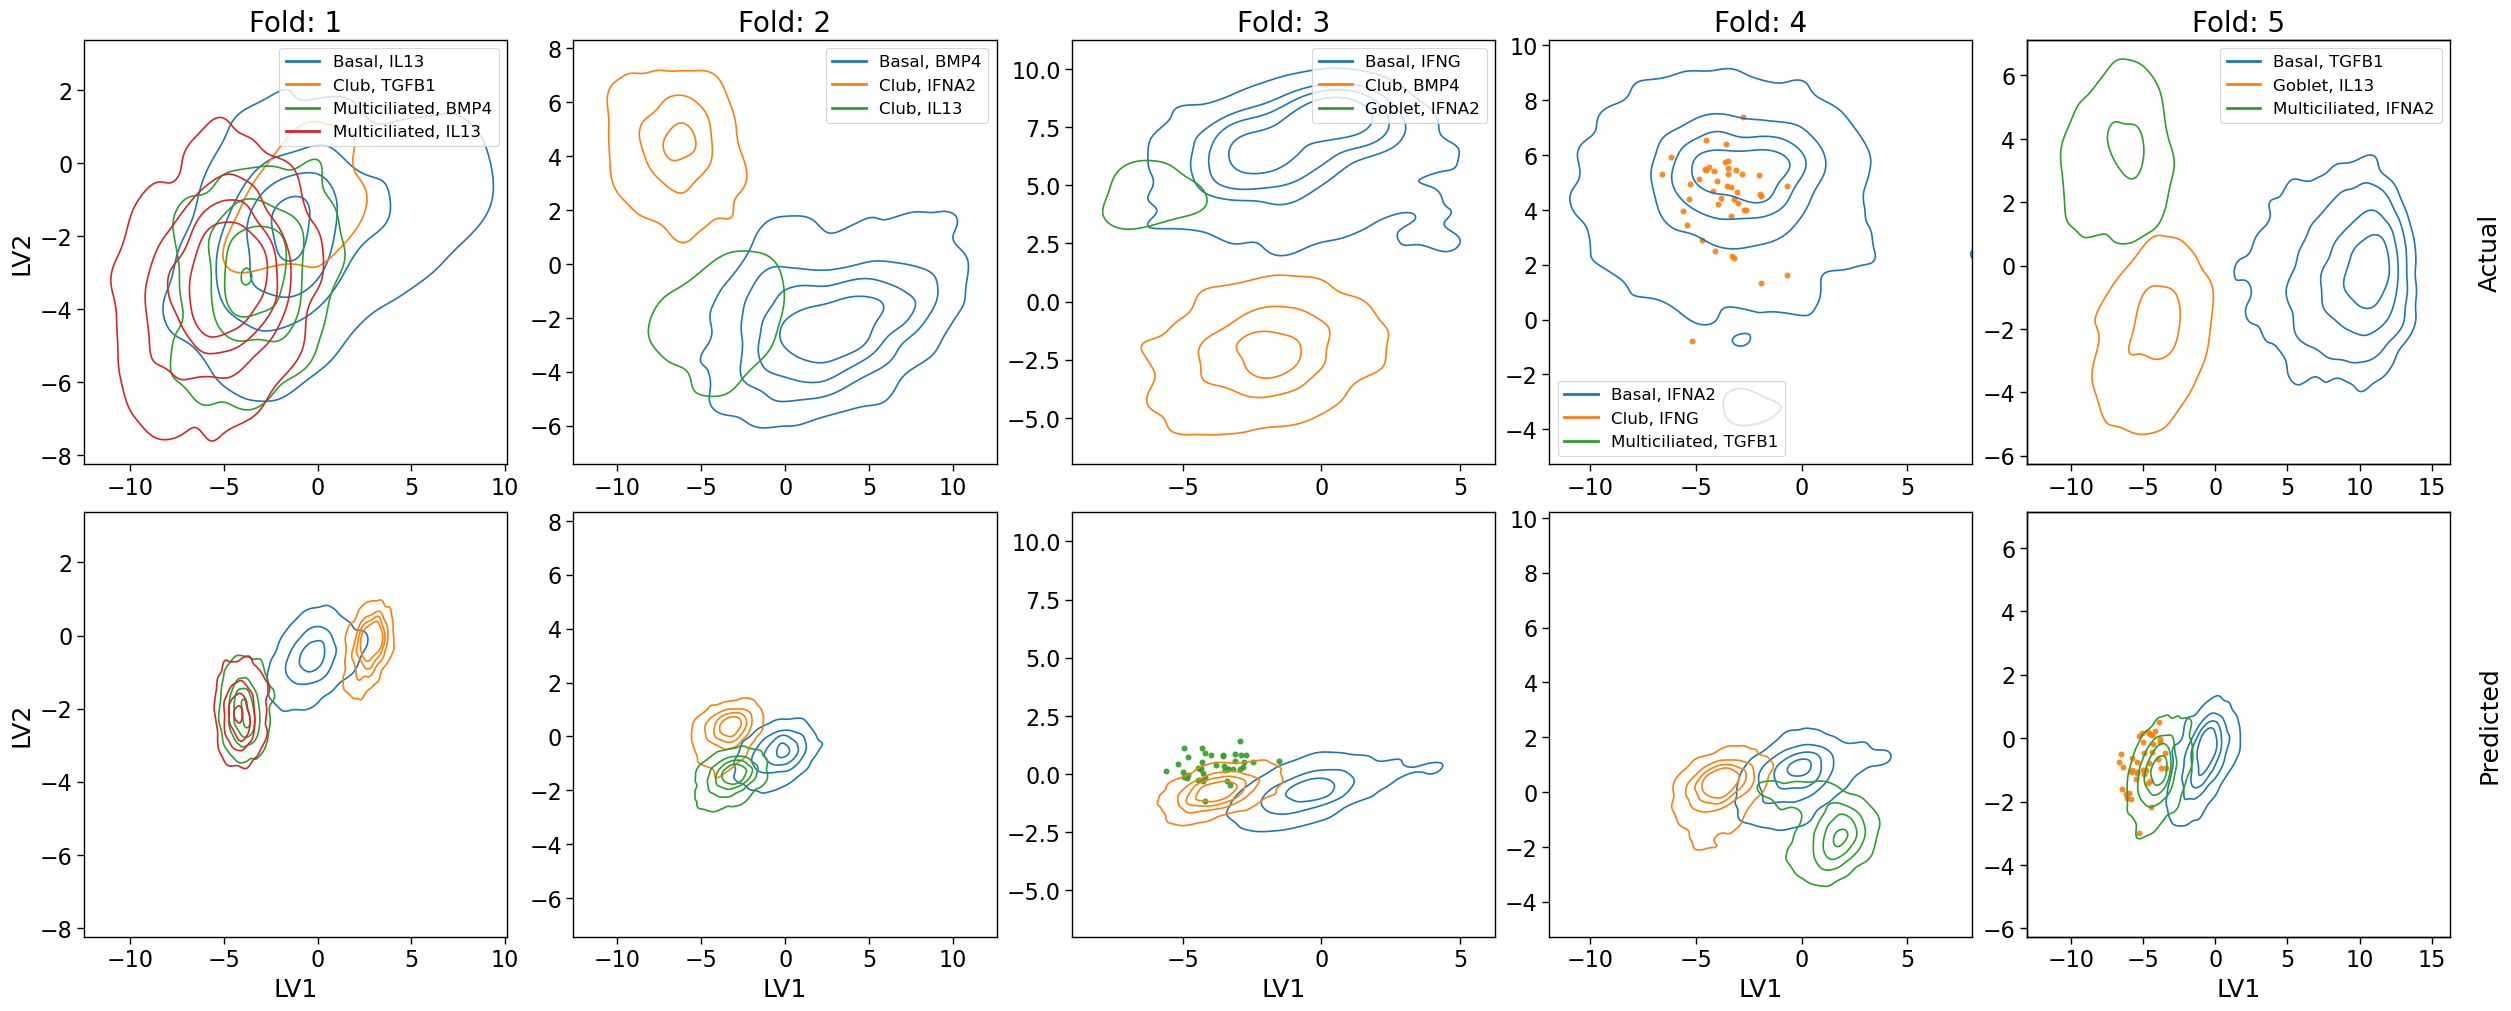

In [8]:
fig, ax = plt.subplots(nrows = 2, ncols = n_folds,
                       figsize = (5 * n_folds, 10),
                       constrained_layout = True)
if n_folds == 1:
    ax = np.array(ax).reshape(2, 1)

for fold in range(n_folds):
    plot_fold_column(fold = fold,
                     ls = 'pls',
                     group_col = 'condition',
                     ax = ax[:, fold],
                     min_points_kde = 50, 
                     is_last_col = (fold == n_folds - 1))
    
for i in range(ax.shape[0]): 
    for j in range(ax.shape[1]):
        if j == 0:
            ax[i, j].set_ylabel('LV2')
        else:
            ax[i,j].set_ylabel('')

        if i == (ax.shape[0]) - 1:
            ax[i, j].set_xlabel('LV1')
        else:
            ax[i,j].set_xlabel('')


We can see that while predicted data separation is more condensed, relative positioning in PLS space is generally (but not always) consistent with actual. 

## Test-Condition Specific Space

In [9]:
@contextmanager
def suppress_all_output():
    """
    Suppress stdout, stderr, warnings, tqdm, and most parallel chatter.
    """
    # save originals
    old_stdout = sys.stdout
    old_stderr = sys.stderr

    try:
        # redirect stdout / stderr
        sys.stdout = open(os.devnull, 'w')
        sys.stderr = open(os.devnull, 'w')

        # silence warnings
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")

            # silence tqdm globally
            os.environ["TQDM_DISABLE"] = "1"

            yield

    finally:
        # restore
        sys.stdout.close()
        sys.stderr.close()
        sys.stdout = old_stdout
        sys.stderr = old_stderr

        os.environ.pop("TQDM_DISABLE", None)

assessment_kwargs = {
    'n_perm': 100, 
    'get_q2_pval': True, 
    'get_r2_pval': False, 
    'get_accuracy_pval': False,
    'n_folds': 5, 
    'seed': 888
}
bl_assessment_kwargs = {
    'n_perm': None, 
    'get_q2_pval': False, 
    'get_r2_pval': False, 
    'get_accuracy_pval': False,
    'n_folds': 5, 
    'seed': 888
    
}

def clear_tfadata(tf_adata_actual, tf_adata_predicted):
    cols = [pert_col, cat_col, 'condition', 'batch', 'barcode']
    tf_adata_actual.obs = tf_adata_actual.obs[cols].copy()
    tf_adata_predicted.obs = tf_adata_predicted.obs[cols].copy()

    del tf_adata_actual.obsm['X_pls'], tf_adata_actual.obsm['X_umap_pls']
    del tf_adata_predicted.obsm['X_pls'], tf_adata_predicted.obsm['X_umap_pls']
    
    return tf_adata_actual, tf_adata_predicted


### Test-Condition Specific Space: Projection of Predicted onto Actual
Instead, let's fit PLS models on the specific test conditions. Because we only visualize separation in the first two latent variables, we will only run PLS to these two components. We will ensure the PLS model fits are significant using the Q2Y p-value compares to a null distribution generated by 100 permutations (as in the standard pipeline).

In [10]:
def test_condition_specific_pls_fits(tf_adata_actual, tf_adata_predicted, baseline = False):
    """Refits PLS on the only the actual test conditions specifically separated by condition, 
    rather than on all data separated by perturbation """
    
    if not baseline:
        tf_adata_actual, tf_adata_predicted = clear_tfadata(tf_adata_actual, tf_adata_predicted)
    # hacky way of running ls.pls_da, that only allows pert_col or cat_col
    pert_og = tf_adata_actual.obs[pert_col].copy()
    tf_adata_actual.obs[pert_col] = tf_adata_actual.obs['condition'].copy()

    with suppress_all_output():
        models, X_pls = ls.pls_da(
            adata = tf_adata_actual, 
            n_components = 2, 
            assess = True, 
            enc_X = None, enc_Y = None, control_confounders = None, 
            separate_by = 'perturbation', # actually separating by condition 
            pert_col = pert_col, 
            cat_col = cat_col, 
            component_selection_kwargs = np.nan, # no component selection
            assessment_kwargs = assessment_kwargs if not baseline else bl_assessment_kwargs, # only needs to be checked once
            n_cores = n_cores, 
            verbose = False
        )

    tf_adata_actual.obsm['X_pls'] = X_pls
    tf_adata_actual.obs[pert_col] = pert_og

    pls_model = models['pls_model']
    
    if not baseline:
        q2y_pval = pls_model.assessment_metrics['Q2Y']['pval']
        if  q2y_pval > 0.05:
            print('The Q2Y value {:.4f} is not significant for fold {}'.format(q2y_pval, fold))

    X_pred_pls = pls_model.transform(tf_adata_predicted.X)
    tf_adata_predicted.obsm['X_pls'] = X_pred_pls
    
    return tf_adata_actual, tf_adata_predicted

# redfine plotting with this additional step
def plot_fold_column(fold, ls, group_col, ax, min_points_kde = 75, is_last_col = False):
    tf_adata_actual, tf_adata_predicted = load_test_tfadata(fold)
    tf_adata_actual, tf_adata_predicted = test_condition_specific_pls_fits(tf_adata_actual, tf_adata_predicted, baseline = False)
    cats = plot_fold_column_(tf_adata_actual, tf_adata_predicted, 
                     ls, group_col, ax, min_points_kde, is_last_col)
    return cats


100%|█████████████████████████████████████████████| 5/5 [00:34<00:00,  6.96s/it]


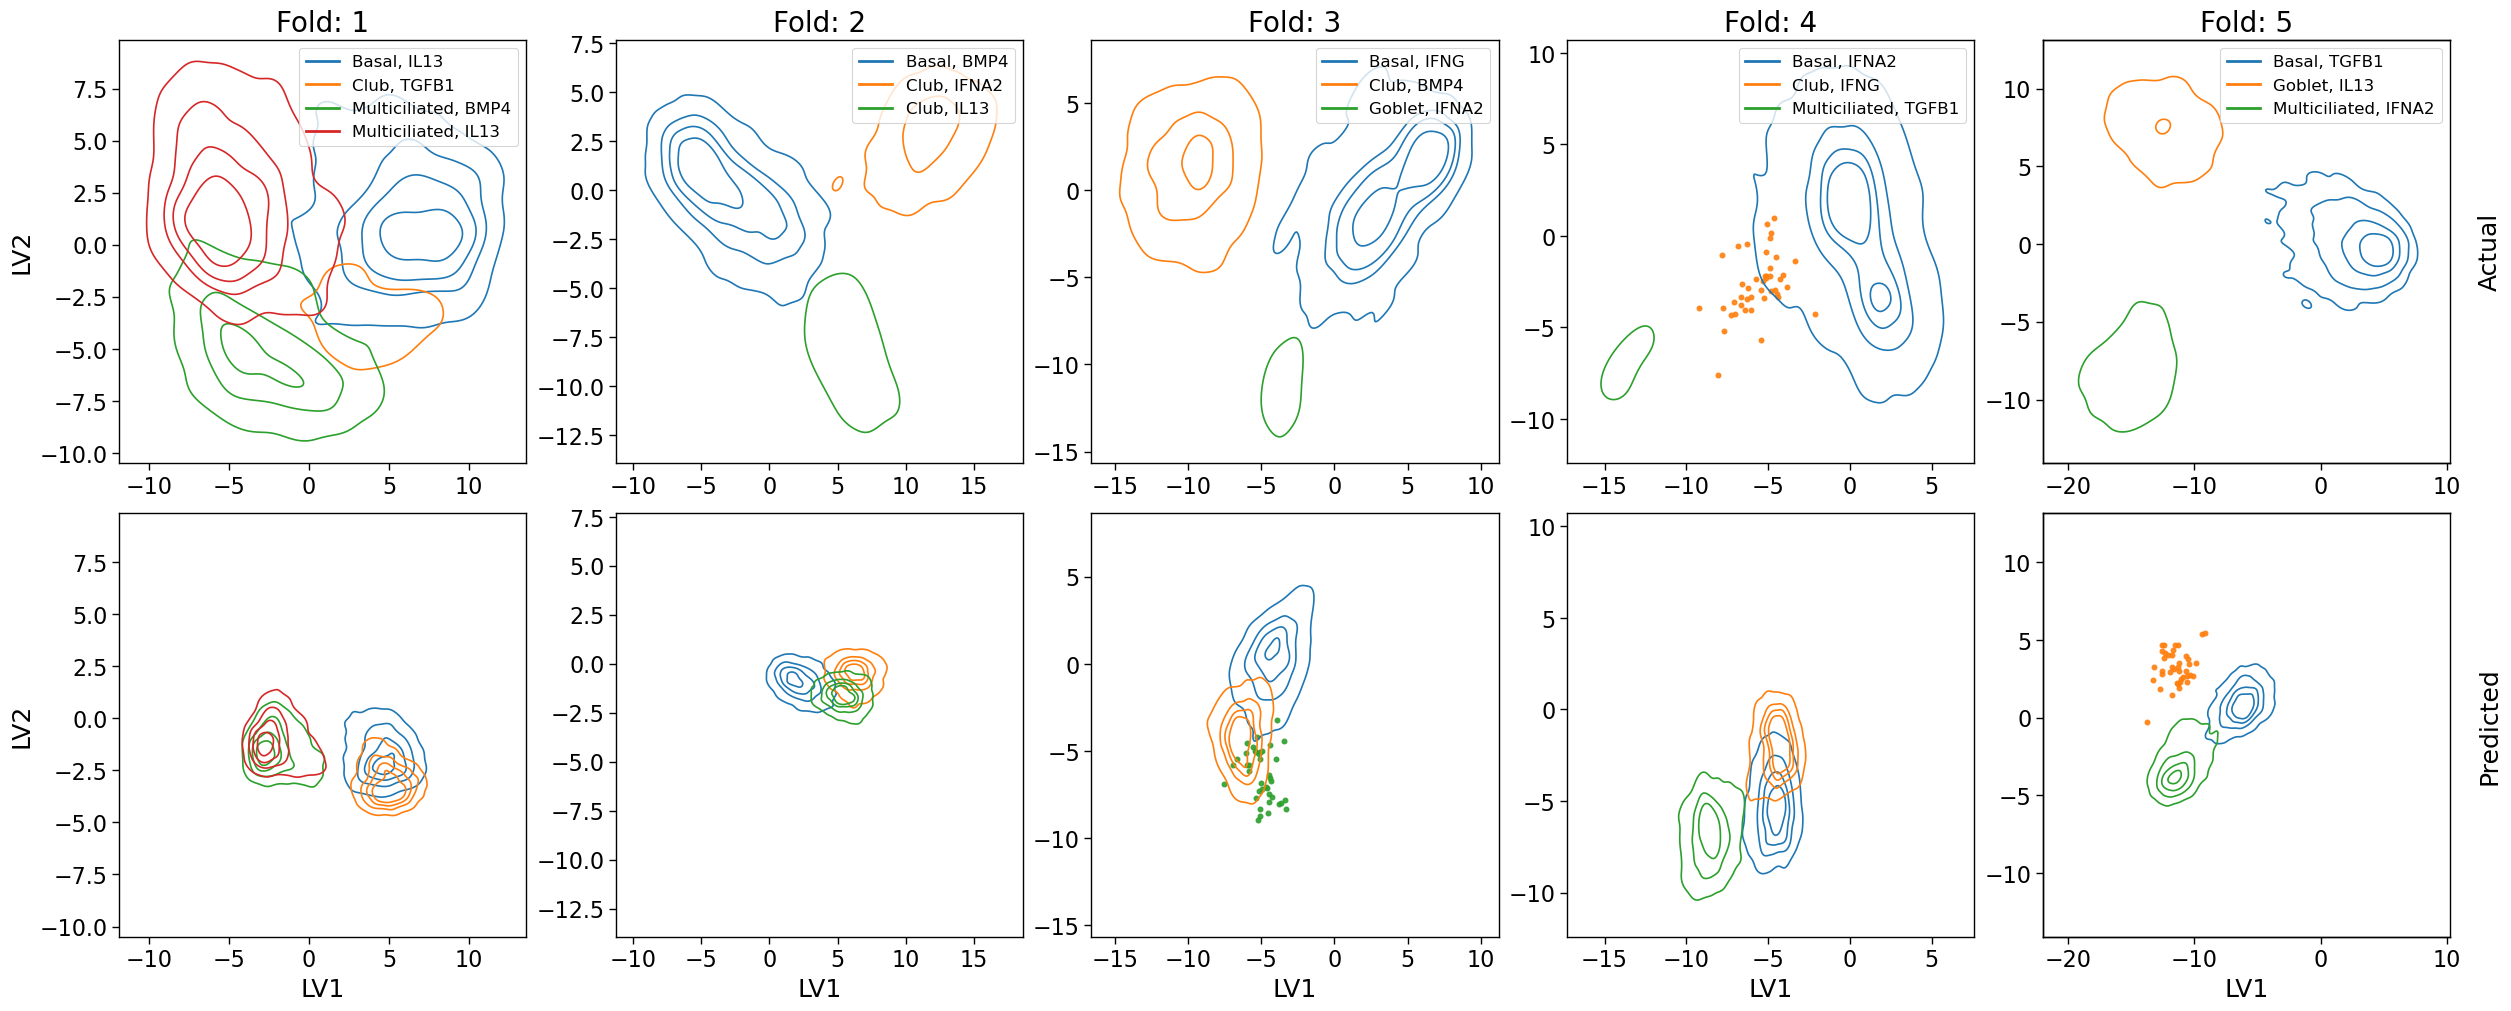

In [11]:
fig, ax = plt.subplots(nrows = 2, ncols = n_folds,
                       figsize = (5 * n_folds, 10),
                       constrained_layout = True)
if n_folds == 1:
    ax = np.array(ax).reshape(2, 1)

for fold in trange(n_folds):
    plot_fold_column(fold = fold,
                     ls = 'pls',
                     group_col = 'condition',
                     ax = ax[:, fold],
                     min_points_kde = 50, 
                     is_last_col = (fold == n_folds - 1))

for i in range(ax.shape[0]): 
    for j in range(ax.shape[1]):
        if j == 0:
            ax[i, j].set_ylabel('LV2')
        else:
            ax[i,j].set_ylabel('')

        if i == (ax.shape[0]) - 1:
            ax[i, j].set_xlabel('LV1')
        else:
            ax[i,j].set_xlabel('')

These visuals much more strongly demonstrate the decent relative positioning of condition-specific test predictions relative to actual. Additionally:

- All PLS model fits to 2 components are significant, so this isn't just fitting noise
- Predictions are projected into the actual data space (not jointly embedded), making this a reasonably stringent eyeball test metric.

### Test-Condition Specific Space: Joint Embedding of Predicted onto Actual

Let's repeat the above, but actually fit the PLS on both the predicted and actual data together, rather than projecting predictions into the PLS space fit on the actual

In [12]:
def test_condition_specific_pls_embeddings(tf_adata_actual, tf_adata_predicted):
    """Refits PLS on the only the actual AND predicted test conditions specifically separated by condition, 
    rather than on all data separated by perturbation """
    
    tf_adata_actual, tf_adata_predicted = clear_tfadata(tf_adata_actual, tf_adata_predicted)
    
    tf_adata_proj = sc.concat([tf_adata_actual, tf_adata_predicted])


    # hacky way of running ls.pls_da, that only allows pert_col or cat_col
    pert_og = tf_adata_proj.obs[pert_col].copy()
    tf_adata_proj.obs[pert_col] = tf_adata_proj.obs['condition'].copy()

    with suppress_all_output():
        models, X_pls = ls.pls_da(
            adata = tf_adata_proj, 
            n_components = 2, 
            assess = True, 
            enc_X = None, enc_Y = None, control_confounders = None, 
            separate_by = 'perturbation', # actually separating by condition 
            pert_col = pert_col, 
            cat_col = cat_col, 
            component_selection_kwargs = np.nan, # no component selection
            assessment_kwargs = assessment_kwargs, 
            n_cores = n_cores, 
            verbose = False
        )

    tf_adata_proj.obsm['X_pls'] = X_pls
    tf_adata_proj.obs[pert_col] = pert_og

    pls_model = models['pls_model']
    q2y_pval = pls_model.assessment_metrics['Q2Y']['pval']
    if  q2y_pval > 0.05:
        print('The Q2Y value {:.4f} is not significant for fold {}'.format(q2y_pval, fold))

    predicted_mask = (tf_adata_proj.obs.batch == 'predicted')

    tf_adata_predicted = tf_adata_proj[predicted_mask, :].copy()
    tf_adata_actual = tf_adata_proj[~predicted_mask, :].copy()
    
    return tf_adata_actual, tf_adata_predicted

# redfine plotting with this additional step
def plot_fold_column(fold, ls, group_col, ax, min_points_kde = 75, is_last_col = False):
    tf_adata_actual, tf_adata_predicted = load_test_tfadata(fold)
    tf_adata_actual, tf_adata_predicted = test_condition_specific_pls_embeddings(tf_adata_actual, tf_adata_predicted)
    cats = plot_fold_column_(tf_adata_actual, tf_adata_predicted, 
                     ls, group_col, ax, min_points_kde, is_last_col)
    return cats


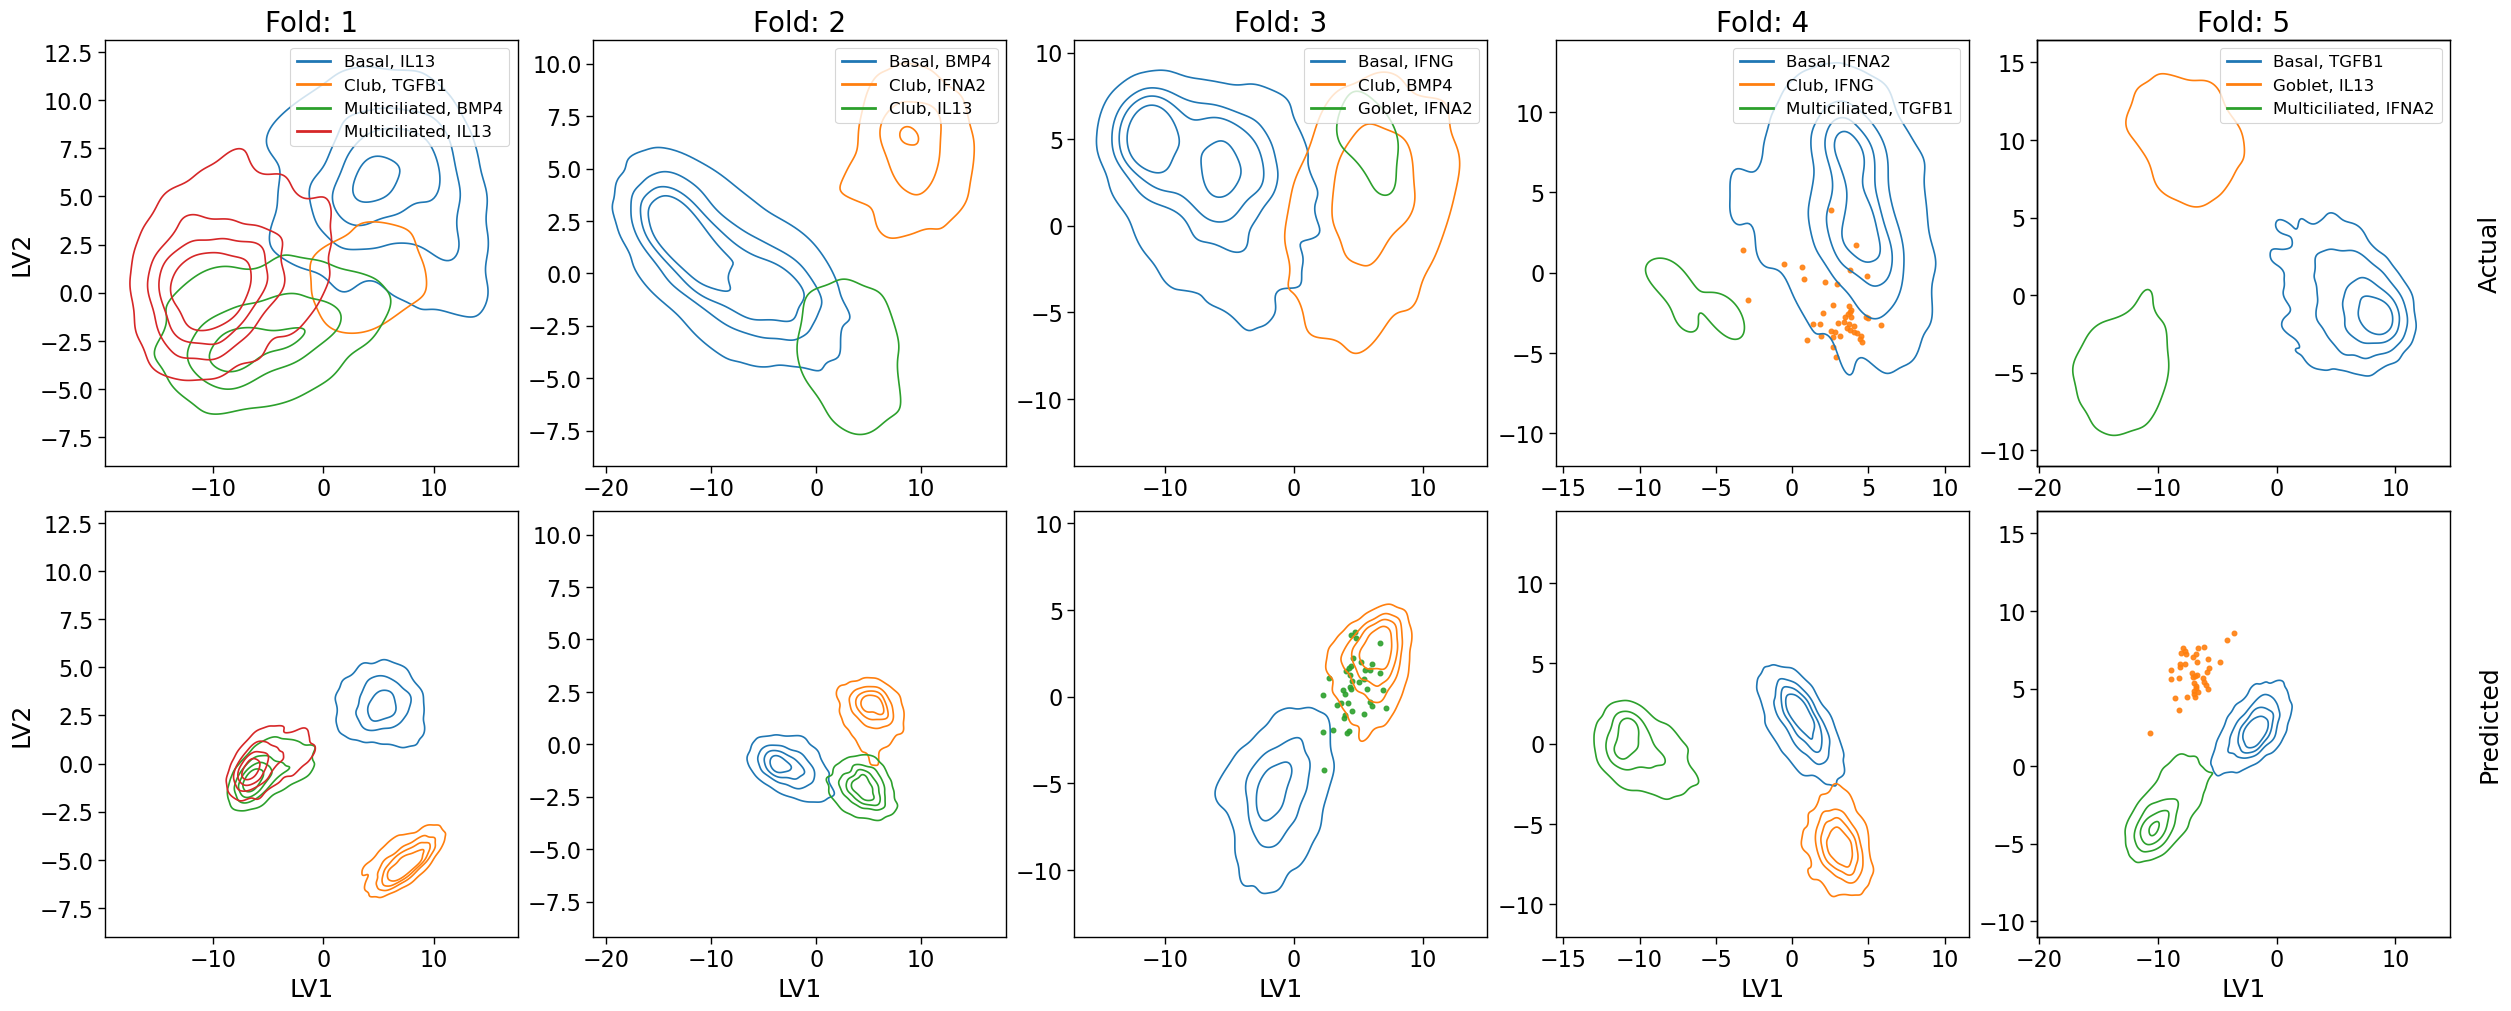

In [13]:
fig, ax = plt.subplots(nrows = 2, ncols = n_folds,
                       figsize = (5 * n_folds, 10),
                       constrained_layout = True)
if n_folds == 1:
    ax = np.array(ax).reshape(2, 1)

for fold in range(n_folds):
    plot_fold_column(fold = fold,
                     ls = 'pls',
                     group_col = 'condition',
                     ax = ax[:, fold],
                     min_points_kde = 50, 
                     is_last_col = (fold == n_folds - 1))
    
for i in range(ax.shape[0]): 
    for j in range(ax.shape[1]):
        if j == 0:
            ax[i, j].set_ylabel('LV2')
        else:
            ax[i,j].set_ylabel('')

        if i == (ax.shape[0]) - 1:
            ax[i, j].set_xlabel('LV1')
        else:
            ax[i,j].set_xlabel('')

This looks slightly better, but is less stringent numerically. For presentation purposes, we can use either 1.2.1 or 1.2.2, though we will probably use 1.2.1 (more stringent). However, all three versions show reasonable prediction power as an eyeball test metric. 

## Comparison to baselines

Emulating the approach from 1.2.1 (projecting predictions into the condition-specific PCA), we will visualize what the baseline model predictions as well as the psuedo-bulked by condition scLEMBAS predictions. 

Note that baseline models psuedobulk by perturbation, so they are repeated for each perturbation regardless of cell type. For linear and RF baselines, in instances where the same perturbation is present across multiple test conditions (only relevant for Fold 1), some slight jitter is added to see the scatter points. For the training mean baseline, jitter is added to all points (since it's just the same prediction).

While the RMSE/Pearson metrics  may quantitatively outperform scLEMBAS, this will give as an eyeball test metric sense of how baselines compare. 

Scatter triangles are psueo-bulked predictions, scatter points/KDE are actual data.

In [14]:
def pb_clear_tfadata(tf_adata_actual):
    cols = [pert_col, cat_col, 'condition', 'batch']

    tf_adata_actual.obs = tf_adata_actual.obs[cols].copy()

    for k in copy.deepcopy(tf_adata_actual.obsm.keys()):
        del tf_adata_actual.obsm[k]
    for k in copy.deepcopy(tf_adata_actual.varm.keys()):
        del tf_adata_actual.varm[k]
    for k in copy.deepcopy(tf_adata_actual.obsp.keys()):
        del tf_adata_actual.obsp[k]
    
    return tf_adata_actual


def get_pb_baseline(fold, baseline_type):
    # actual data
    split = get_split(fold, author)
    test_conds = split['test_conds']

    test_cond_mask = tf_adata.obs.condition.isin(test_conds)
    tf_adata_actual = tf_adata[test_cond_mask,:].copy()
    tf_adata_actual.obs['batch'] = 'actual'

    tf_adata_actual = pb_clear_tfadata(tf_adata_actual)

    
    if baseline_type in ['RF', 'mean', 'linear']: # pb baseline
        _, y_pred_baseline_condition = pb_y_pred(fold, author, baseline_type, tf_adata, pert_col)
    elif baseline_type == 'scLEMBAS_prediction': # psuedobulked scLEMBAS predictions
        key = 'none_{}'.format(fold)
        tf_adata_merged = merged_adatas[key].copy()

        split = get_split(fold, author)
        test_conds = split['test_conds']

        test_cond_mask = tf_adata_merged.obs.condition.isin(test_conds)
        tf_adata_test = tf_adata_merged[test_cond_mask,:].copy()
        predicted_mask = (tf_adata_test.obs.batch == 'predicted')
        tf_adata_predicted = tf_adata_test[predicted_mask, :].copy()
        tf_adata_predicted = pb_clear_tfadata(tf_adata_predicted)
        y_pred_baseline_condition = distances.psuedobulk_adata(adata = tf_adata_predicted, groupby_col = 'condition')
    
    assert sorted(y_pred_baseline_condition.index) == sorted(test_conds), 'Predicted and test conditions disagree'
    
    cats, perts = zip(*(cond.split('^') for cond in y_pred_baseline_condition.index))
    pred_obs = pd.DataFrame(
        {
            pert_col: list(perts),
            cat_col: list(cats), 
            'condition': y_pred_baseline_condition.index.tolist(), 
            'batch': ['predicted']*y_pred_baseline_condition.shape[0], 

        }
    )
    pred_obs.index = pred_obs.index.astype(str) # avoid implicitmodification warning
    y_pred_baseline_condition.reset_index(drop = True, inplace = True)
    tf_adata_predicted = sc.AnnData(X = y_pred_baseline_condition, obs = pred_obs)        

    return tf_adata_actual, tf_adata_predicted

bt_map = {'scLEMBAS_prediction': 'scLEMBAS',
 'RF': 'Random Forest Baseline',
 'linear': 'Linear Baseline',
 'mean': 'Training Mean Baseline'}

def plot_fold_column_baseline(tf_adata_actual, tf_adata_predicted, baseline_type,
                     ls, group_col, ax, min_points_kde = 75, is_last_col = False):

    adata_dict = {
        'Actual': tf_adata_actual,
        'Predicted': tf_adata_predicted
    }

    cats = None

    # ----- ACTUAL: KDE (+ scatter fallback) -----
    adata = tf_adata_actual

    viz_df = pd.DataFrame(adata.obsm['X_{}'.format(ls)])
    viz_df.columns = ['{}{}'.format(ls_label_dict[ls], i+1) for i in range(viz_df.shape[1])]

    viz_df[group_col] = adata.obs[group_col].astype(str).apply(lambda x: x.replace('^', ', ')).tolist()
    viz_df[group_col].apply
    cats = sorted(viz_df[group_col].unique())
    viz_df[group_col] = pd.Categorical(viz_df[group_col],
                                       categories = cats, ordered = True)

    small_cats = []
    for cat in cats:
        tmp = viz_df[viz_df[group_col] == cat]

        # too few points
        if tmp.shape[0] < min_points_kde:
            small_cats.append(cat)
            continue

        # singular / near-singular geometry (no 2D contour possible)
        xvar = np.var(tmp['{}1'.format(ls_label_dict[ls])].values)
        yvar = np.var(tmp['{}2'.format(ls_label_dict[ls])].values)
        if (xvar <= 1e-12) or (yvar <= 1e-12):
            small_cats.append(cat)

    viz_df_kde = viz_df[~viz_df[group_col].isin(small_cats)]

    if viz_df_kde.shape[0] > 0:
        sns.kdeplot(data = viz_df_kde,
                    x = '{}1'.format(ls_label_dict[ls]),
                    y = '{}2'.format(ls_label_dict[ls]),
                    hue = group_col, fill = False, levels = 5,
                    warn_singular = False,
                    ax = ax)

    # scatter overlay for small / singular groups (so they never disappear)
    palette = sns.color_palette(n_colors = len(cats))
    color_map = {cat: color for (cat, color) in zip(cats, palette)}

    for cat in small_cats:
        tmp = viz_df[viz_df[group_col] == cat]
        ax.scatter(tmp['{}1'.format(ls_label_dict[ls])],
                   tmp['{}2'.format(ls_label_dict[ls])],
                   s = 12, alpha = 0.9,
                   color = color_map[cat])

    # ----- ensure same bounds (robust quantiles) across actual + predicted -----
    xmin, xmax, ymin, ymax = np.inf, -np.inf, np.inf, -np.inf

    q_lo = 0.005
    q_hi = 0.995

    for (adata_type, adata) in adata_dict.items():
        X = adata.obsm['X_{}'.format(ls)]

        x_lo = np.quantile(X[:, 0], q_lo)
        x_hi = np.quantile(X[:, 0], q_hi)
        y_lo = np.quantile(X[:, 1], q_lo)
        y_hi = np.quantile(X[:, 1], q_hi)

        if x_lo < xmin:
            xmin = x_lo
        if x_hi > xmax:
            xmax = x_hi
        if y_lo < ymin:
            ymin = y_lo
        if y_hi > ymax:
            ymax = y_hi

    # small padding
    pad = 0.15
    dx = (xmax - xmin) * pad
    dy = (ymax - ymin) * pad
    xmin = xmin - dx
    xmax = xmax + dx
    ymin = ymin - dy
    ymax = ymax + dy

    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)

    # ----- PREDICTED: pseudobulk points; baseline-specific jitter rules (big triangles) -----
    adata = tf_adata_predicted

    viz_df_pred = pd.DataFrame(adata.obsm['X_{}'.format(ls)])
    viz_df_pred.columns = ['{}{}'.format(ls_label_dict[ls], i+1) for i in range(viz_df_pred.shape[1])]

    viz_df_pred[group_col] = adata.obs[group_col].astype(str).apply(lambda x: x.replace('^', ', ')).tolist()
    viz_df_pred[group_col].apply
    viz_df_pred[group_col] = pd.Categorical(viz_df_pred[group_col],
                                            categories = cats, ordered = True)

    viz_df_pred[pert_col] = adata.obs[pert_col].astype(str).tolist()

    xcol = '{}1'.format(ls_label_dict[ls])
    ycol = '{}2'.format(ls_label_dict[ls])

    # jitter scale based on final axis span (so it is always visible)
    x_jitter = 0.025 * (xmax - xmin)
    y_jitter = 0.025 * (ymax - ymin)

    viz_df_pred['_x_plot'] = viz_df_pred[xcol].values.copy()
    viz_df_pred['_y_plot'] = viz_df_pred[ycol].values.copy()

    # jitter rules:
    # - RF/linear: jitter duplicates by pert_col
    # - scLEMBAS_prediction: no jitter
    # - mean: jitter ALL points (so stacked identical means are visible)
    if baseline_type in ['RF', 'linear']:
        for pert, idx in viz_df_pred.groupby(pert_col).groups.items():
            idx = list(idx)
            if len(idx) <= 1:
                continue

            # deterministic offsets: 0, +1, -1, +2, -2, ...
            offsets = []
            for k in range(len(idx)):
                if k == 0:
                    offsets.append(0.0)
                else:
                    m = (k + 1) // 2
                    sign = 1.0 if (k % 2 == 1) else -1.0
                    offsets.append(sign * float(m))
            offsets = np.array(offsets)

            viz_df_pred.loc[idx, '_x_plot'] = viz_df_pred.loc[idx, '_x_plot'].values + offsets * x_jitter
            viz_df_pred.loc[idx, '_y_plot'] = viz_df_pred.loc[idx, '_y_plot'].values + offsets * y_jitter

    elif baseline_type == 'mean':
        # deterministic offsets across ALL rows: 0, +1, -1, +2, -2, ...
        n = viz_df_pred.shape[0]
        offsets = []
        for k in range(n):
            if k == 0:
                offsets.append(0.0)
            else:
                m = (k + 1) // 2
                sign = 1.0 if (k % 2 == 1) else -1.0
                offsets.append(sign * float(m))
        offsets = np.array(offsets)

        viz_df_pred['_x_plot'] = viz_df_pred['_x_plot'].values + offsets * x_jitter
        viz_df_pred['_y_plot'] = viz_df_pred['_y_plot'].values + offsets * y_jitter

    # (baseline_type == 'scLEMBAS_prediction') -> no jitter

    # plot triangles (one per row; colored by condition)
    for cat in cats:
        tmp = viz_df_pred[viz_df_pred[group_col] == cat]
        if tmp.shape[0] == 0:
            continue

        ax.scatter(tmp['_x_plot'],
                   tmp['_y_plot'],
                   s = 180,
                   marker = '^',
                   color = color_map[cat],
                   zorder = 5)

    # clear seaborn auto-legend (and any accidental mpl legend)
    ax.legend_.remove() if ax.legend_ is not None else None

    if is_last_col:
        ax_r = ax.twinx()                 
        ax_r.set_ylabel(bt_map[baseline_type], labelpad = 20)
        ax_r.set_yticks([])              
        ax_r.tick_params(right=False)
        ax_r.spines['right'].set_visible(False)

    # legend (once, if caller wants it): colors = condition (lines), triangles inherit same colors
    handles = []
    labels = []
    palette = sns.color_palette(n_colors = len(cats))
    for color, cat in zip(palette, cats):
        handles.append(Line2D([0], [0], color = color, lw = 2))
        labels.append(cat)
    ax.legend(handles = handles, labels = labels, title = '')

    return cats


100%|█████████████████████████████████████████████| 5/5 [00:36<00:00,  7.28s/it]


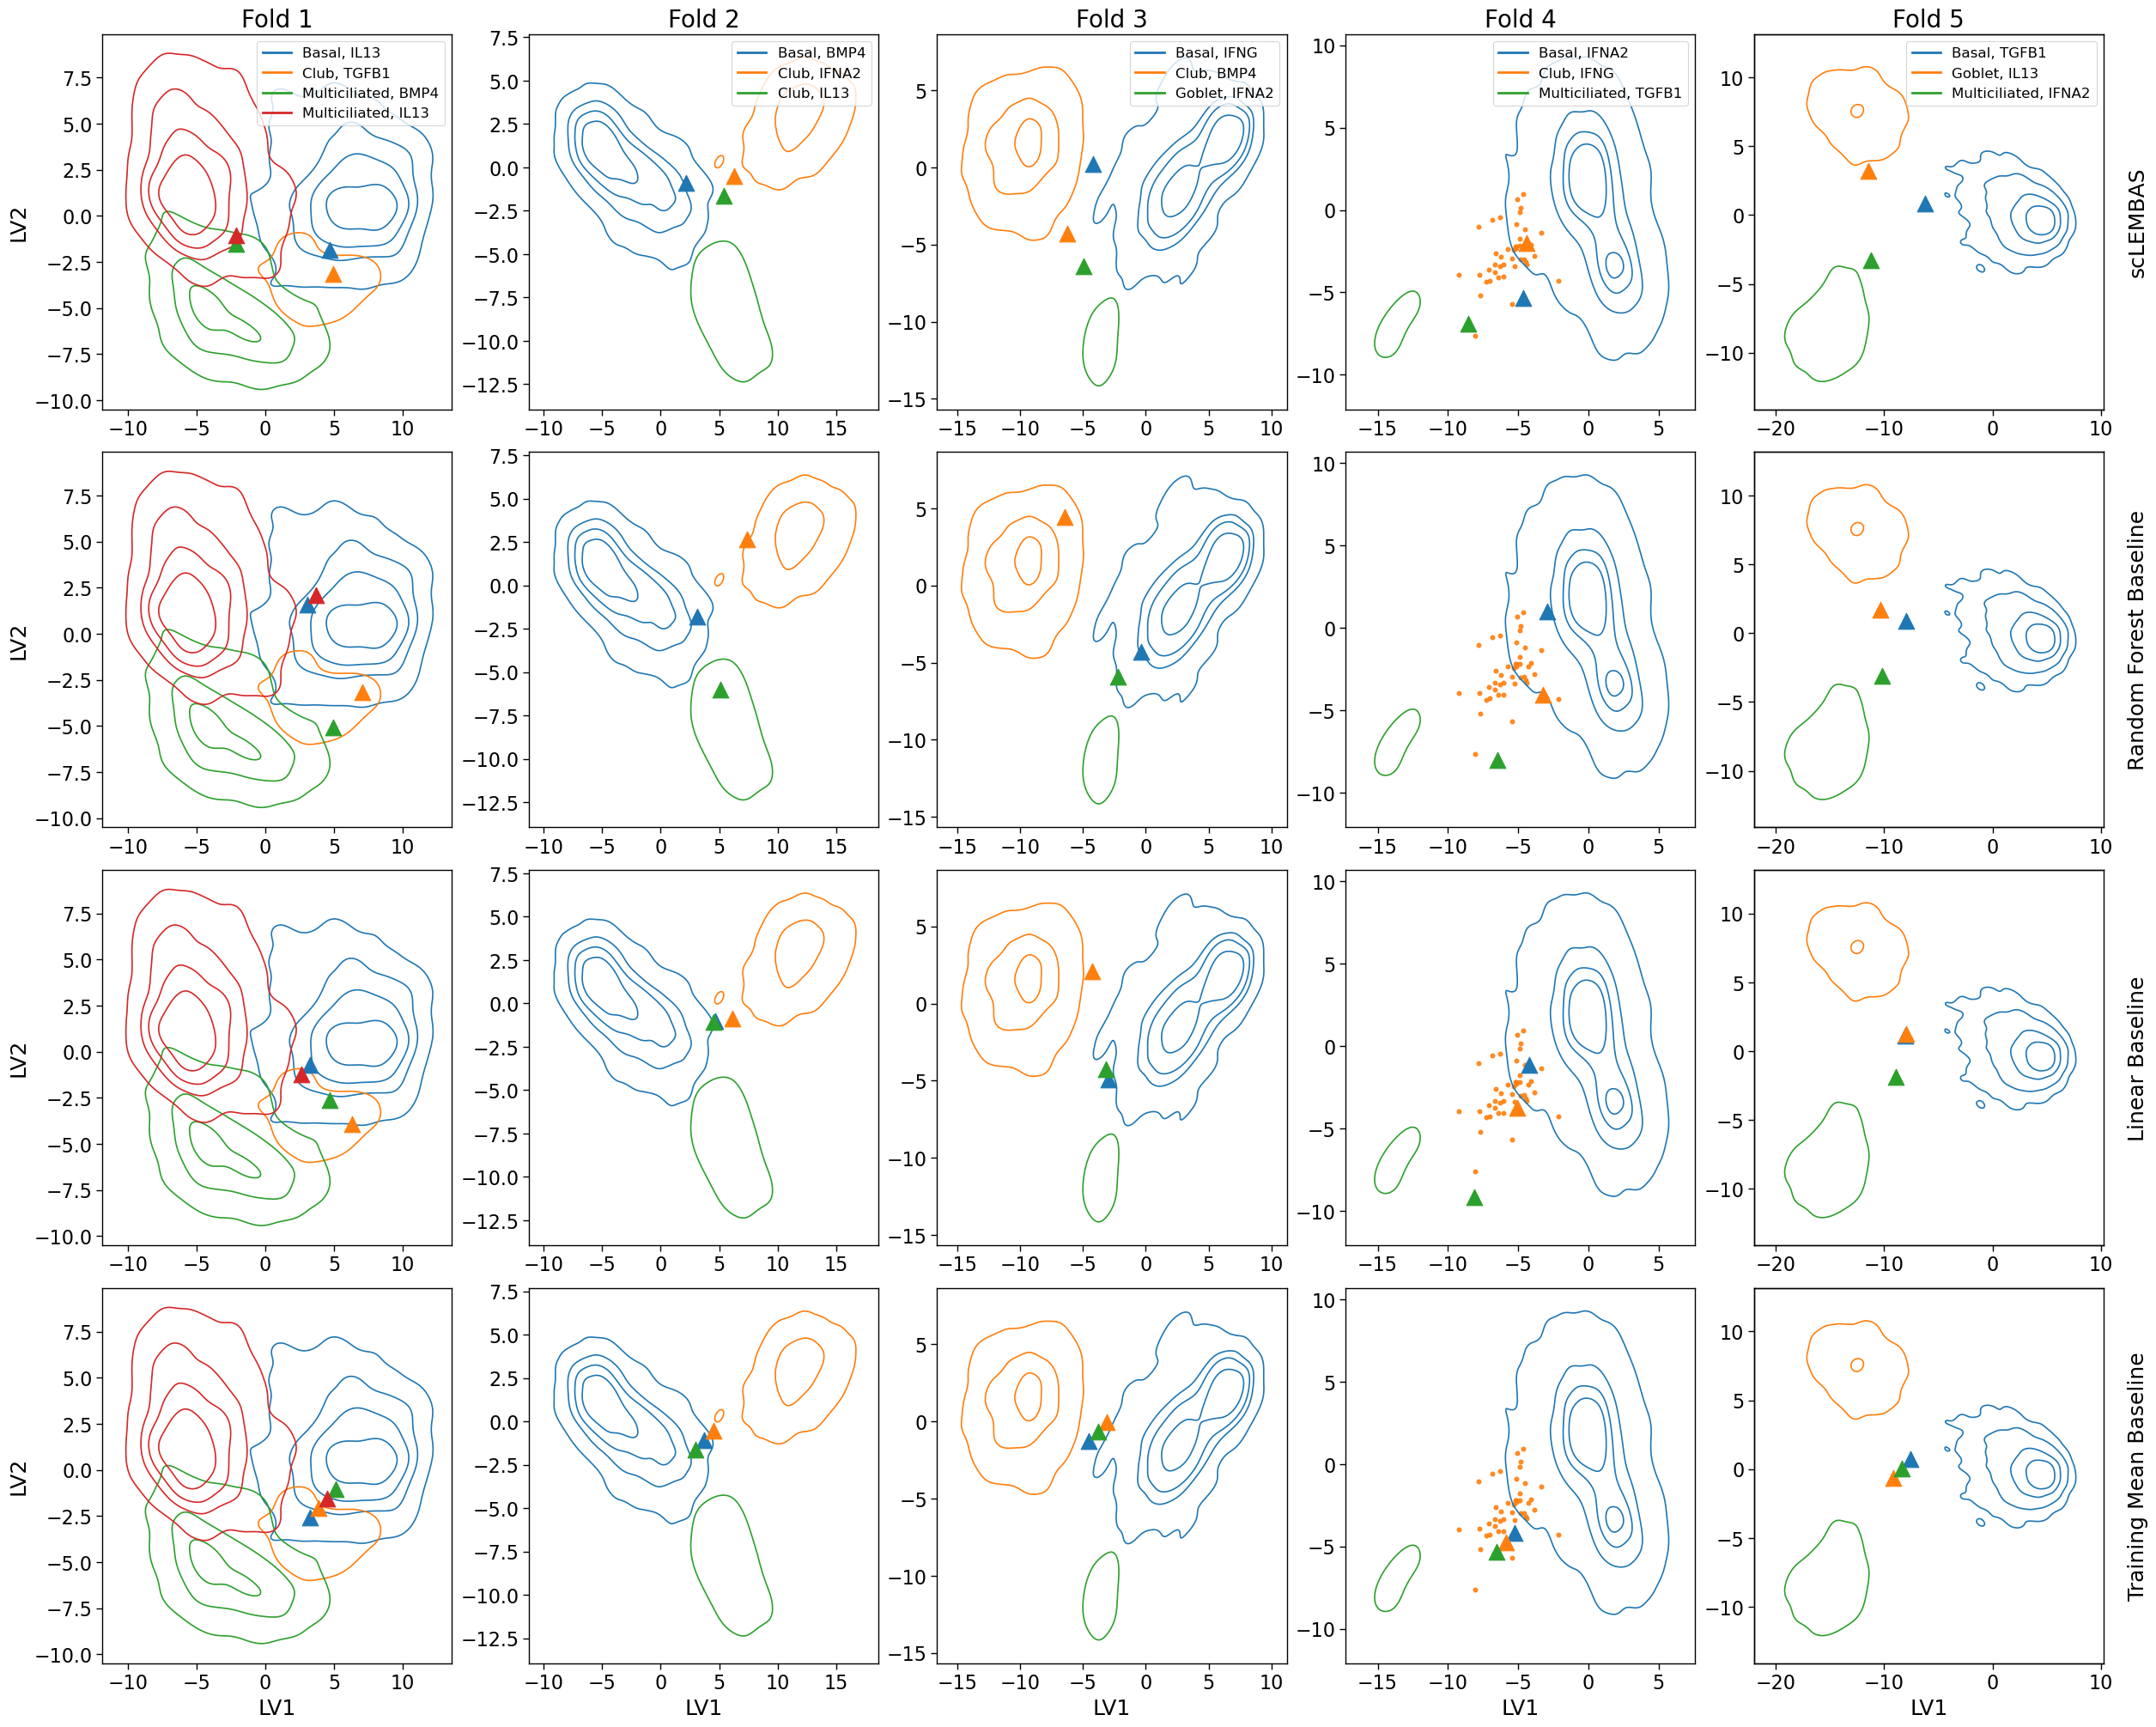

In [15]:
def plot_fold_column(fold, baseline_type, ls, group_col, ax, min_points_kde = 75, is_last_col = False):
    tf_adata_actual, tf_adata_predicted = get_pb_baseline(fold, baseline_type)
    tf_adata_actual, tf_adata_predicted = test_condition_specific_pls_fits(tf_adata_actual, tf_adata_predicted, baseline = True)
    cats = plot_fold_column_baseline(tf_adata_actual, tf_adata_predicted, baseline_type,
                     ls, group_col, ax, min_points_kde, is_last_col)
    return cats

baseline_types = ['scLEMBAS_prediction', 'RF', 'linear', 'mean']

fig, ax = plt.subplots(nrows = len(baseline_types), ncols = n_folds,
                       figsize = (5 * n_folds, 5 * len(baseline_types)),
                       constrained_layout = True)

if n_folds == 1:
    ax = np.array(ax).reshape(len(baseline_types), 1)

for i, baseline_type in enumerate(baseline_types):
    for fold in trange(n_folds):
        plot_fold_column(fold = fold,
                         baseline_type = baseline_type, 
                         ls = 'pls',
                         group_col = 'condition',
                         ax = ax[i, fold],
                         min_points_kde = 50, 
                         is_last_col = (fold == n_folds - 1))
        if i == 0:
            ax[i, fold].set_title('Fold {}'.format(fold + 1))
        else:
            if ax[i, fold].legend_ is not None:
                ax[i, fold].legend_.remove()

for i in range(ax.shape[0]): 
    for j in range(ax.shape[1]):
        if j == 0:
            ax[i, j].set_ylabel('LV2')
        else:
            ax[i,j].set_ylabel('')

        if i == (ax.shape[0]) - 1:
            ax[i, j].set_xlabel('LV1')
        else:
            ax[i,j].set_xlabel('')
            
            

Here, we see that despite what the loss quantiatively reports, scLEMBAS visually outperforms the training mean and linear baseline, which have limited condition-specific separation, and performs comparably to the random forest baseline (some folds RF looks visually better, others scLEMBAS does). Furthermore, as we saw previously, scLEMBAS also captures more dispersion, rather than just the psuedo-bulked mean (and also learned network toplogy; we will explore mechanistic utility in later notebooks). 

Also, the loss metrics were in the full feature space. In PLS space, this indicates that scLEMBAS is capturing the relevant features that drive condition-specific separation. This tells us that, while our model predictions via the loss metrics used in [Ahlmann-Eltze et al](https://doi.org/10.1038/s41592-025-02772-6) and [Csendes et al](https://doi.org/10.1186/s12864-025-11600-2) perform worse than baselines (consistent with results in those papers), the quantitative metrics assessing those baselines do not suffice in describing model performance.

# Test Counterfactuals

This previous section visualized the latent space of all test conditions together. Now, we want to see how the model is performing on the counterfactual specifically (withing a cell type, capturing the perturbation from the input contro). 

# Component Specific Contributions